# 09 — UV Abundances: C/O and N/O from Rest-Frame UV Lines

**Purpose:** Derive C/O and UV-based N/O from UV semi-forbidden and
resonance lines in a dust-corrected composite spectrum.  Demonstrates
the new UV abundance support in `jwspecabund`.

### Lines used

| Ion | Lines | Abundance |
|-----|-------|-----------|
| C2+ | CIII] 1907 + 1909 | C++/H+ |
| C3+ | CIV 1548 + 1551 | C+++/H+ |
| N2+ | NIII] 1749 + 1752 | N++/H+ |
| N3+ | NIV] 1483 + 1486 | N+++/H+ |
| N4+ | NV 1239 + 1243 | N4+/H+ (manual emissivity) |
| O2+ | [OIII] 4959 + 5007 | O++/H+ |

### Methodology

1. Fit UV + optical lines on the rest-frame stacked spectrum
2. Dust correction from Balmer decrement (Ha/Hb)
3. Electron temperature from [OIII] 4363/(4959+5007)
4. Electron density from CIII] 1907/1909
5. Ionic abundances via PyNEB (+ manual NV emissivity)
6. C/O = (C2+ + C3+) / O2+ (Jones+2023)
7. N/O = (N2+ + N3+ + N4+) / O2+
8. MC error propagation with pre-computed emissivity grids

**Data:** `stack_all_Muv19_21_DustCorrected.npz` — rest-frame composite
spectrum (z = 0, 1000–7500 Å, 129 galaxies).

**Date:** 2026-02-23

In [1]:
import jwspecfit
from jwspecfit.lines import REST_LINES_A
from jwspecfit.resolution import R_from_pixels
from jwspecabund.dust import salim_attenuation, compute_Av_from_balmer
from jwspecabund.forward import hbeta_emissivity_aller84, _nv_emissivity
import matplotlib.pyplot as plt
import numpy as np
import pyneb as pn

print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"pyneb     v{pn.__version__}")

jwspecfit  v1.0.0
pyneb     v1.1.28


## 1. Load the stacked spectrum

In [2]:
spec = jwspecfit.read_npz("../../data/stack_all_Muv19_21_DustCorrected.npz", z=0.0)

# Estimate R from pixel spacing
R_func = R_from_pixels(spec.wave_um)

v = spec.mask_valid()
print(f"Pixels:     {spec.n_pix} ({v.sum()} valid)")
print(f"Wave range: {spec.wave_um[v].min()*1e4:.0f} – {spec.wave_um[v].max()*1e4:.0f} Å")
print(f"R at 1500 Å: {R_func(0.15):.0f}")
print(f"R at 5000 Å: {R_func(0.50):.0f}")

Pixels:     13000 (12976 valid)
Wave range: 1012 – 7500 Å
R at 1500 Å: 1500
R at 5000 Å: 5000


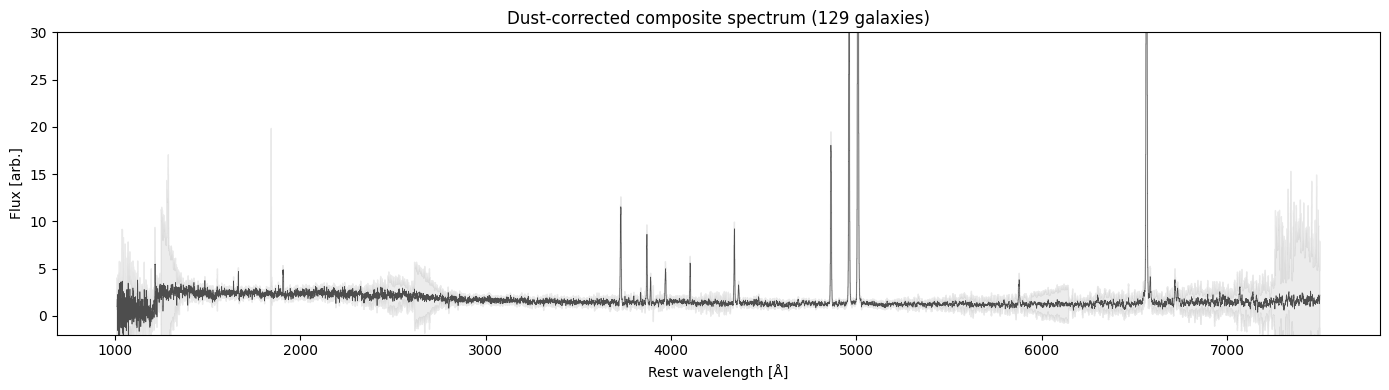

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(spec.wave_um[v] * 1e4, spec.flux_ujy[v], where="mid", lw=0.5, color="0.3")
ax.fill_between(
    spec.wave_um[v] * 1e4,
    (spec.flux_ujy - spec.err_ujy)[v],
    (spec.flux_ujy + spec.err_ujy)[v],
    step="mid", alpha=0.15, color="0.5",
)
ax.set_xlabel(r"Rest wavelength [Å]")
ax.set_ylabel(r"Flux [arb.]")
ax.set_title("Dust-corrected composite spectrum (129 galaxies)")
ax.set_ylim(-2, 30)
plt.tight_layout()

## 2. Fit UV lines (~1200–2000 Å)

In [4]:
uv_lines = [
    "NV_1", "NV_2",
    "NIV_1483", "NIV_1486",
    "CIV_1", "CIV_2",
    "HEII_1640",
    "OIII_1661", "OIII_1666",
    "NIII_1749", "NIII_1752",
    "SiIII_1", "SiIII_2",
    "CIII]_1907", "CIII]",
]

# Rest-frame spectrum at z=0, so observed = rest
result_uv = jwspecfit.fit_lines(
    spec, z=0.0, R=R_func,
    lines=uv_lines,
    wave_range_A=(1200, 2000),
    moving_average=100, n_boot=1000,
)

print(f"Lines fitted: {len(result_uv.lines)}")
print(f"chi2/dof:     {result_uv.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_uv.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Resolving power: R ≈ 4250 (range 1000–7500)


Bootstrap (narrow): 100%|██████████| 1000/1000 [03:46<00:00,  4.41iter/s]

Lines fitted: 15
chi2/dof:     1.22

Line                       Flux          Err      SNR
----------------------------------------------------
NV_1                  1.820e-29    1.808e-28      0.1
NV_2                  8.009e-17    2.976e-17      2.7
NIV_1483              2.238e-17    7.805e-18      2.9
NIV_1486              3.146e-17    8.238e-18      3.8
CIV_1                 1.081e-17    5.983e-18      1.8
CIV_2                 3.301e-17    1.193e-17      2.8
HEII_1640             3.566e-17    6.642e-18      5.4
OIII_1661             2.057e-17    5.408e-18      3.8
OIII_1666             4.952e-17    5.765e-18      8.6
NIII_1749             1.149e-17    4.304e-18      2.7
NIII_1752             6.398e-18    3.517e-18      1.8
SiIII_1               1.738e-17    4.496e-18      3.9
SiIII_2               1.589e-17    4.247e-18      3.7
CIII]_1907            3.699e-17    6.046e-18      6.1
CIII]                 5.176e-17    7.271e-18      7.1


In [5]:
fig_interactive = jwspecfit.plot_fit_interactive(result_uv, wave_unit="A")
fig_interactive.show()

## 3. Fit optical lines (~4800–6800 Å)

In [6]:
optical_lines = [
    "HBETA", "OIII_4363", "OIII_4959", "OIII_5007",
    "Ha", "NII_6585", "SII_6718", "SII_6732",
]

result_opt = jwspecfit.fit_lines(
    spec, z=0.0, R=R_func,
    lines=optical_lines,
    wave_range_A=(4300, 6800),
    moving_average=100, n_boot=1000,
)

print(f"Lines fitted: {len(result_opt.lines)}")
print(f"chi2/dof:     {result_opt.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_opt.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Resolving power: R ≈ 4250 (range 1000–7500)


Bootstrap (broad1): 100%|██████████| 1000/1000 [02:04<00:00,  8.06iter/s]

Lines fitted: 10
chi2/dof:     0.58

Line                       Flux          Err      SNR
----------------------------------------------------
HBETA                 9.674e-17    4.276e-18     22.6
OIII_4363             1.488e-17    1.081e-18     13.8
OIII_4959             2.440e-16    5.188e-18     47.0
OIII_5007             7.245e-16    1.559e-17     46.5
Ha                    2.788e-16    7.932e-18     35.2
NII_6585              8.006e-18    1.449e-18      5.5
SII_6718              8.051e-18    1.344e-18      6.0
SII_6732              4.025e-18    1.007e-18      4.0
Ha_BROAD              2.006e-18    4.115e-18      0.5
HBETA_BROAD           2.176e-17    3.396e-18      6.4


In [7]:
fig_interactive = jwspecfit.plot_fit_interactive(result_opt, wave_unit="A")
fig_interactive.show()

## 3b. Fit [OII] 3726+3729

Fit the [OII] doublet to obtain O+/H+ for the optical N/O comparison.

In [8]:
oii_lines = ["OII_3726", "OII_3729"]

result_oii = jwspecfit.fit_lines(
    spec, z=0.0, R=R_func,
    lines=oii_lines,
    wave_range_A=(3600, 3850),
    moving_average=100, n_boot=1000,
)

print(f"Lines fitted: {len(result_oii.lines)}")
print(f"chi2/dof:     {result_oii.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_oii.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Resolving power: R ≈ 4250 (range 1000–7500)


Bootstrap (narrow): 100%|██████████| 1000/1000 [00:13<00:00, 72.57iter/s]

Lines fitted: 2
chi2/dof:     1.15

Line                       Flux          Err      SNR
----------------------------------------------------
OII_3726              1.680e-17    3.360e-17      0.5
OII_3729              1.095e-16    3.422e-17      3.2


## 4. Dust correction

Derive A_V from the Ha/Hb Balmer decrement.  The spectrum is labelled
as dust-corrected in the filename but we verify here.

In [9]:
def get_flux(result, name):
    lr = result.lines.get(name)
    if lr is None:
        return np.nan, np.nan
    return lr.flux, lr.flux_err

f_Ha, e_Ha = get_flux(result_opt, "Ha")
f_Hb, e_Hb = get_flux(result_opt, "HBETA")

print(f"Ha/Hb = {f_Ha/f_Hb:.3f}  (Case B = 2.86)")

Av_val, Av_err = compute_Av_from_balmer(
    f_Ha, f_Hb, e_Ha, e_Hb,
    law="salim", intrinsic_ratio=2.86,
    wave_num_A=REST_LINES_A["Ha"],
    wave_den_A=REST_LINES_A["HBETA"],
)
Av = max(Av_val, 0.0)
print(f"A_V = {Av:.3f} +/- {Av_err:.3f}")

# Dust correction helper
def dust_correct(flux, flux_err, rest_wave_A, Av):
    if Av <= 0 or not np.isfinite(Av):
        return flux, flux_err
    A_lam = salim_attenuation(np.array([rest_wave_A]), Av)[0]
    factor = 10.0 ** (0.4 * A_lam)
    return flux * factor, flux_err * factor

Ha/Hb = 2.882  (Case B = 2.86)
A_V = 0.016 +/- 0.105


## 5. Electron temperature and density

In [10]:
O3 = pn.Atom('O', 3)
C3 = pn.Atom('C', 3)
N3_atom = pn.Atom('N', 3)
N4_atom = pn.Atom('N', 4)
C4 = pn.Atom('C', 4)
H1 = pn.RecAtom('H', 1)

# Dust-corrected optical fluxes
f_4363, e_4363 = get_flux(result_opt, "OIII_4363")
f_4959, e_4959 = get_flux(result_opt, "OIII_4959")
f_5007, e_5007 = get_flux(result_opt, "OIII_5007")

f_4363_c, _ = dust_correct(f_4363, e_4363, 4364.44, Av)
f_4959_c, _ = dust_correct(f_4959, e_4959, 4961.68, Av)
f_5007_c, _ = dust_correct(f_5007, e_5007, 5009.64, Av)

ratio_oiii = f_4363_c / (f_4959_c + f_5007_c)
print(f"[OIII] 4363 SNR = {f_4363/e_4363:.1f}")
print(f"[OIII] 4363/(4959+5007) = {ratio_oiii:.4f}")

# Te from [OIII]
ne_init = 1000.0  # initial guess
Te_high = O3.getTemDen(
    ratio_oiii, den=ne_init,
    to_eval="L(4363) / (L(4959) + L(5007))",
    start_x=3.5, end_x=5.0, log=True,
)
print(f"Te(O2+) = {Te_high:.0f} K")

# ne from CIII] 1907/1909
f_c3_07, e_c3_07 = get_flux(result_uv, "CIII]_1907")
f_c3_09, e_c3_09 = get_flux(result_uv, "CIII]")

ne = ne_init
if f_c3_07 > 0 and f_c3_09 > 0:
    f_c3_07_c, _ = dust_correct(f_c3_07, e_c3_07, 1906.68, Av)
    f_c3_09_c, _ = dust_correct(f_c3_09, e_c3_09, 1908.73, Av)
    ratio_ciii = f_c3_07_c / f_c3_09_c
    ne_ciii = C3.getTemDen(ratio_ciii, tem=Te_high, wave1=1907, wave2=1909)
    if np.isfinite(ne_ciii) and ne_ciii > 0:
        ne = float(ne_ciii)
        print(f"CIII] 1907/1909 = {ratio_ciii:.3f}  ->  ne = {ne:.0f} cm^-3")
    else:
        print(f"CIII] ratio = {ratio_ciii:.3f} (outside physical range, using ne={ne:.0f})")
else:
    print(f"CIII] not detected, using ne = {ne:.0f} cm^-3")

# Recompute Te with refined ne
Te_high = O3.getTemDen(
    ratio_oiii, den=ne,
    to_eval="L(4363) / (L(4959) + L(5007))",
    start_x=3.5, end_x=5.0, log=True,
)
print(f"\nFinal Te(O2+) = {Te_high:.0f} K  (ne = {ne:.0f} cm^-3)")

[OIII] 4363 SNR = 13.8
[OIII] 4363/(4959+5007) = 0.0154
Te(O2+) = 15364 K
CIII] 1907/1909 = 0.715  ->  ne = 46454 cm^-3

Final Te(O2+) = 14305 K  (ne = 46454 cm^-3)


## 6. Ionic abundances

All UV ionic abundances use Te(O2+) — appropriate for the high-ionisation zone.

In [11]:
def get_j_Hb(Te, ne):
    """Hbeta emissivity with Aller 1984 fallback for Te > 30,000 K."""
    try:
        val = H1.getEmissivity(Te, ne, wave=4861)
        if np.isfinite(val):
            return val
    except Exception:
        pass
    return hbeta_emissivity_aller84(Te)


f_Hb_c, e_Hb_c = dust_correct(f_Hb, e_Hb, 4864.04, Av)
j_Hb = get_j_Hb(Te_high, ne)

print(f"{'Ion':<12s} {'Lines':<20s} {'Flux':>12s} {'X/H+':>12s} {'12+log':>10s}")
print("-" * 68)

# O2+/H+ from [OIII] 5007
j_5007 = O3.getEmissivity(Te_high, ne, wave=5007)
Opp = (f_5007_c / f_Hb_c) * (j_Hb / j_5007)
print(f"{'O2+':<12s} {'[OIII] 5007':<20s} {f_5007_c:12.3e} {Opp:12.3e} {12+np.log10(Opp):10.3f}")

# C2+/H+ from CIII] 1907+1909
f_ciii = 0.0
for name in ["CIII]_1907", "CIII]"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_ciii += f
Cpp = np.nan
if f_ciii > 0:
    f_ciii_c, _ = dust_correct(f_ciii, 0, 1908.0, Av)
    eps = C3.getEmissivity(Te_high, ne, wave=1907) + C3.getEmissivity(Te_high, ne, wave=1909)
    Cpp = (f_ciii_c / f_Hb_c) * (j_Hb / eps)
    print(f"{'C2+':<12s} {'CIII] 1907+1909':<20s} {f_ciii_c:12.3e} {Cpp:12.3e} {12+np.log10(Cpp):10.3f}")

# C3+/H+ from CIV 1548+1551
f_civ = 0.0
for name in ["CIV_1", "CIV_2"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_civ += f
Cppp = np.nan
if f_civ > 0:
    f_civ_c, _ = dust_correct(f_civ, 0, 1549.0, Av)
    eps_civ = C4.getEmissivity(Te_high, ne, wave=1548) + C4.getEmissivity(Te_high, ne, wave=1551)
    Cppp = (f_civ_c / f_Hb_c) * (j_Hb / eps_civ)
    print(f"{'C3+':<12s} {'CIV 1548+1551':<20s} {f_civ_c:12.3e} {Cppp:12.3e} {12+np.log10(Cppp):10.3f}")

# N2+/H+ from NIII] 1749+1752
f_niii = 0.0
for name in ["NIII_1749", "NIII_1752"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_niii += f
Npp = np.nan
if f_niii > 0:
    f_niii_c, _ = dust_correct(f_niii, 0, 1750.0, Av)
    eps_niii = N3_atom.getEmissivity(Te_high, ne, wave=1749) + N3_atom.getEmissivity(Te_high, ne, wave=1752)
    Npp = (f_niii_c / f_Hb_c) * (j_Hb / eps_niii)
    print(f"{'N2+':<12s} {'NIII] 1749+1752':<20s} {f_niii_c:12.3e} {Npp:12.3e} {12+np.log10(Npp):10.3f}")

# N3+/H+ from NIV] 1483+1486
f_niv = 0.0
for name in ["NIV_1483", "NIV_1486"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_niv += f
Nppp = np.nan
if f_niv > 0:
    f_niv_c, _ = dust_correct(f_niv, 0, 1486.5, Av)
    eps_niv = N4_atom.getEmissivity(Te_high, ne, wave=1487) + N4_atom.getEmissivity(Te_high, ne, wave=1483)
    Nppp = (f_niv_c / f_Hb_c) * (j_Hb / eps_niv)
    print(f"{'N3+':<12s} {'NIV] 1483+1486':<20s} {f_niv_c:12.3e} {Nppp:12.3e} {12+np.log10(Nppp):10.3f}")

# N4+/H+ from NV 1239+1243 (manual emissivity)
f_nv = 0.0
for name in ["NV_1", "NV_2"]:
    f, e = get_flux(result_uv, name)
    if np.isfinite(f) and f > 0:
        f_nv += f
Npppp = np.nan
if f_nv > 0:
    f_nv_c, _ = dust_correct(f_nv, 0, 1240.0, Av)
    eps_nv = _nv_emissivity(Te_high, ne, 1239) + _nv_emissivity(Te_high, ne, 1243)
    if eps_nv > 0:
        Npppp = (f_nv_c / f_Hb_c) * (j_Hb / eps_nv)
        print(f"{'N4+':<12s} {'NV 1239+1243':<20s} {f_nv_c:12.3e} {Npppp:12.3e} {12+np.log10(Npppp):10.3f}")

Ion          Lines                        Flux         X/H+     12+log
--------------------------------------------------------------------
O2+          [OIII] 5007             7.401e-16    9.378e-05      7.972
C2+          CIII] 1907+1909         9.506e-17    2.261e-05      7.354
C3+          CIV 1548+1551           4.716e-17    7.039e-06      6.848
N2+          NIII] 1749+1752         1.916e-17    4.981e-05      7.697
N3+          NIV] 1483+1486          5.809e-17    4.839e-05      7.685
N4+          NV 1239+1243            8.770e-17    2.742e-07      5.438


## 7. C/O and N/O ratios

In [12]:
# C/O = (C2+ + C3+) / O2+
C_total = sum(x for x in [Cpp, Cppp] if np.isfinite(x))
if C_total > 0 and Opp > 0:
    CO = C_total / Opp
    print(f"C/O  = (C2+ + C3+) / O2+ = {CO:.4f}")
    print(f"log(C/O) = {np.log10(CO):.3f}")
    C_ions = {"C2+": Cpp, "C3+": Cppp}
    for ion, val in C_ions.items():
        if np.isfinite(val):
            print(f"  {ion}/C = {val/C_total:.1%}")
else:
    print("C/O not available")

print()

# N/O = (N2+ + N3+ + N4+) / O2+
N_total = sum(x for x in [Npp, Nppp, Npppp] if np.isfinite(x))
if N_total > 0 and Opp > 0:
    NO_uv = N_total / Opp
    print(f"N/O  = (N2+ + N3+ + N4+) / O2+ = {NO_uv:.4f}")
    print(f"log(N/O) = {np.log10(NO_uv):.3f}")
    N_ions = {"N2+": Npp, "N3+": Nppp, "N4+": Npppp}
    for ion, val in N_ions.items():
        if np.isfinite(val):
            print(f"  {ion}/N = {val/N_total:.1%}")
else:
    print("UV N/O not available")

C/O  = (C2+ + C3+) / O2+ = 0.3162
log(C/O) = -0.500
  C2+/C = 76.3%
  C3+/C = 23.7%

N/O  = (N2+ + N3+ + N4+) / O2+ = 1.0501
log(N/O) = 0.021
  N2+/N = 50.6%
  N3+/N = 49.1%
  N4+/N = 0.3%


## 8. Monte Carlo error propagation

Pre-compute emissivity grids as a function of Te, then use vectorised
`np.interp` — same approach as notebook 08.

In [13]:
n_mc = 10000
rng = np.random.default_rng(42)

# Pre-compute emissivity grids
print("Pre-computing emissivity grids ...")
Te_g = np.linspace(5000, 80000, 500)

# [OIII] auroral/nebular ratio R(Te)
R_g = np.array([
    O3.getEmissivity(T, ne, wave=4363) /
    (O3.getEmissivity(T, ne, wave=4959) + O3.getEmissivity(T, ne, wave=5007))
    for T in Te_g
])

# O2+
j_5007_g = np.array([O3.getEmissivity(T, ne, wave=5007) for T in Te_g])
j_Hb_g = np.array([get_j_Hb(T, ne) for T in Te_g])

# C2+ (CIII])
j_ciii_g = np.array([
    C3.getEmissivity(T, ne, wave=1907) + C3.getEmissivity(T, ne, wave=1909)
    for T in Te_g
])

# C3+ (CIV)
j_civ_g = np.array([
    C4.getEmissivity(T, ne, wave=1548) + C4.getEmissivity(T, ne, wave=1551)
    for T in Te_g
])

# N2+ (NIII])
j_niii_g = np.array([
    N3_atom.getEmissivity(T, ne, wave=1749) + N3_atom.getEmissivity(T, ne, wave=1752)
    for T in Te_g
])

# N3+ (NIV]) — must sum BOTH doublet components
j_niv_g = np.array([
    N4_atom.getEmissivity(T, ne, wave=1487) + N4_atom.getEmissivity(T, ne, wave=1483)
    for T in Te_g
])

# N4+ (NV) — manual
j_nv_g = np.array([
    _nv_emissivity(T, ne, 1239) + _nv_emissivity(T, ne, 1243)
    for T in Te_g
])

print("Done.")

Pre-computing emissivity grids ...
Done.


In [14]:
# Collect all fluxes and errors
flux_names = {
    "OIII_4363": (result_opt, 4364.44),
    "OIII_4959": (result_opt, 4961.68),
    "OIII_5007": (result_opt, 5009.64),
    "HBETA":     (result_opt, 4864.04),
    "Ha":        (result_opt, REST_LINES_A["Ha"]),
    "CIII]_1907": (result_uv, 1906.68),
    "CIII]":      (result_uv, 1908.73),
    "CIV_1":      (result_uv, 1548.19),
    "CIV_2":      (result_uv, 1550.77),
    "NIII_1749":  (result_uv, 1748.65),
    "NIII_1752":  (result_uv, 1752.16),
    "NIV_1483":   (result_uv, 1483.32),
    "NIV_1486":   (result_uv, 1486.50),
    "NV_1":       (result_uv, 1238.82),
    "NV_2":       (result_uv, 1242.80),
}

# Draw MC samples
mc_fluxes = {}
for name, (res, rwave) in flux_names.items():
    f, e = get_flux(res, name)
    if np.isfinite(f) and np.isfinite(e) and e > 0:
        mc_fluxes[name] = rng.normal(f, e, size=n_mc)
    else:
        mc_fluxes[name] = np.full(n_mc, np.nan)

# Dust correction (vectorised) — derive Av per sample from Ha/Hb
k_Ha_1 = salim_attenuation(np.array([REST_LINES_A["Ha"]]), 1.0)[0]
k_Hb_1 = salim_attenuation(np.array([4864.04]), 1.0)[0]
dk = k_Ha_1 - k_Hb_1

bal = mc_fluxes["Ha"] / mc_fluxes["HBETA"]
with np.errstate(invalid="ignore", divide="ignore"):
    Av_s = np.where(
        (bal > 0) & (bal > 2.86),
        -2.5 * np.log10(2.86 / bal) / (0.4 * dk),
        0.0,
    )
Av_s = np.clip(Av_s, 0, None)

# k(lambda)/A_V for each rest wavelength
kv = {}
for name, (_, rwave) in flux_names.items():
    kv[name] = salim_attenuation(np.array([rwave]), 1.0)[0]

def dc(name):
    return mc_fluxes[name] * 10.0 ** (0.4 * kv[name] * Av_s)

# Dust-corrected MC fluxes
c_Hb   = dc("HBETA")
c_4363 = dc("OIII_4363")
c_4959 = dc("OIII_4959")
c_5007 = dc("OIII_5007")
c_ciii = dc("CIII]_1907") + dc("CIII]")
c_civ  = dc("CIV_1") + dc("CIV_2")
c_niii = dc("NIII_1749") + dc("NIII_1752")
c_niv  = dc("NIV_1483") + dc("NIV_1486")
c_nv   = dc("NV_1") + dc("NV_2")

# Te from [OIII] ratio
with np.errstate(invalid="ignore", divide="ignore"):
    ratio_s = c_4363 / (c_4959 + c_5007)
Te_s = np.interp(ratio_s, R_g, Te_g)
Te_s[~np.isfinite(ratio_s) | (ratio_s < R_g[0]) | (ratio_s > R_g[-1])] = np.nan

# Interpolate emissivities
bad = ~np.isfinite(Te_s)
def interp_g(grid):
    arr = np.interp(Te_s, Te_g, grid)
    arr[bad] = np.nan
    return arr

ej_5007 = interp_g(j_5007_g)
ej_Hb   = interp_g(j_Hb_g)
ej_ciii = interp_g(j_ciii_g)
ej_civ  = interp_g(j_civ_g)
ej_niii = interp_g(j_niii_g)
ej_niv  = interp_g(j_niv_g)
ej_nv   = interp_g(j_nv_g)

# Ionic abundances (vectorised)
with np.errstate(invalid="ignore", divide="ignore"):
    Opp_s   = (c_5007 / c_Hb) * (ej_Hb / ej_5007)
    Cpp_s   = np.where(c_ciii > 0, (c_ciii / c_Hb) * (ej_Hb / ej_ciii), np.nan)
    Cppp_s  = np.where(c_civ > 0, (c_civ / c_Hb) * (ej_Hb / ej_civ), np.nan)
    Npp_s   = np.where(c_niii > 0, (c_niii / c_Hb) * (ej_Hb / ej_niii), np.nan)
    Nppp_s  = np.where(c_niv > 0, (c_niv / c_Hb) * (ej_Hb / ej_niv), np.nan)
    Npppp_s = np.where((c_nv > 0) & (ej_nv > 0), (c_nv / c_Hb) * (ej_Hb / ej_nv), np.nan)

# C/O and N/O
def pos_or_zero(arr):
    return np.where(np.isfinite(arr) & (arr > 0), arr, 0.0)

C_s = pos_or_zero(Cpp_s) + pos_or_zero(Cppp_s)
N_s = pos_or_zero(Npp_s) + pos_or_zero(Nppp_s) + pos_or_zero(Npppp_s)
O_s = pos_or_zero(Opp_s)

with np.errstate(invalid="ignore", divide="ignore"):
    OH_s = np.where(O_s > 0, 12 + np.log10(O_s), np.nan)
    CO_s = np.where((C_s > 0) & (O_s > 0), np.log10(C_s / O_s), np.nan)
    NO_s = np.where((N_s > 0) & (O_s > 0), np.log10(N_s / O_s), np.nan)

# Report
good = np.isfinite(Te_s) & np.isfinite(OH_s)
print(f"Valid MC samples: {good.sum()}/{n_mc} ({good.sum()/n_mc*100:.0f}%)\n")

def report(arr, label, fmt=".3f"):
    v = arr[np.isfinite(arr)]
    if len(v) == 0:
        print(f"  {label}: no valid samples")
        return
    lo, med, hi = np.percentile(v, [16, 50, 84])
    print(f"  {label:20s} = {med:{fmt}}   +{hi-med:{fmt}} / -{med-lo:{fmt}}")

report(Te_s, "Te [K]", fmt=".0f")
report(OH_s, "12+log(O/H)")
report(CO_s, "log(C/O)")
report(NO_s, "log(N/O) [UV]")

Valid MC samples: 10000/10000 (100%)

  Te [K]               = 14269   +473 / -476
  12+log(O/H)          = 7.976   +0.048 / -0.044
  log(C/O)             = -0.519   +0.067 / -0.066
  log(N/O) [UV]        = -0.000   +0.097 / -0.104


## 9. Summary plots

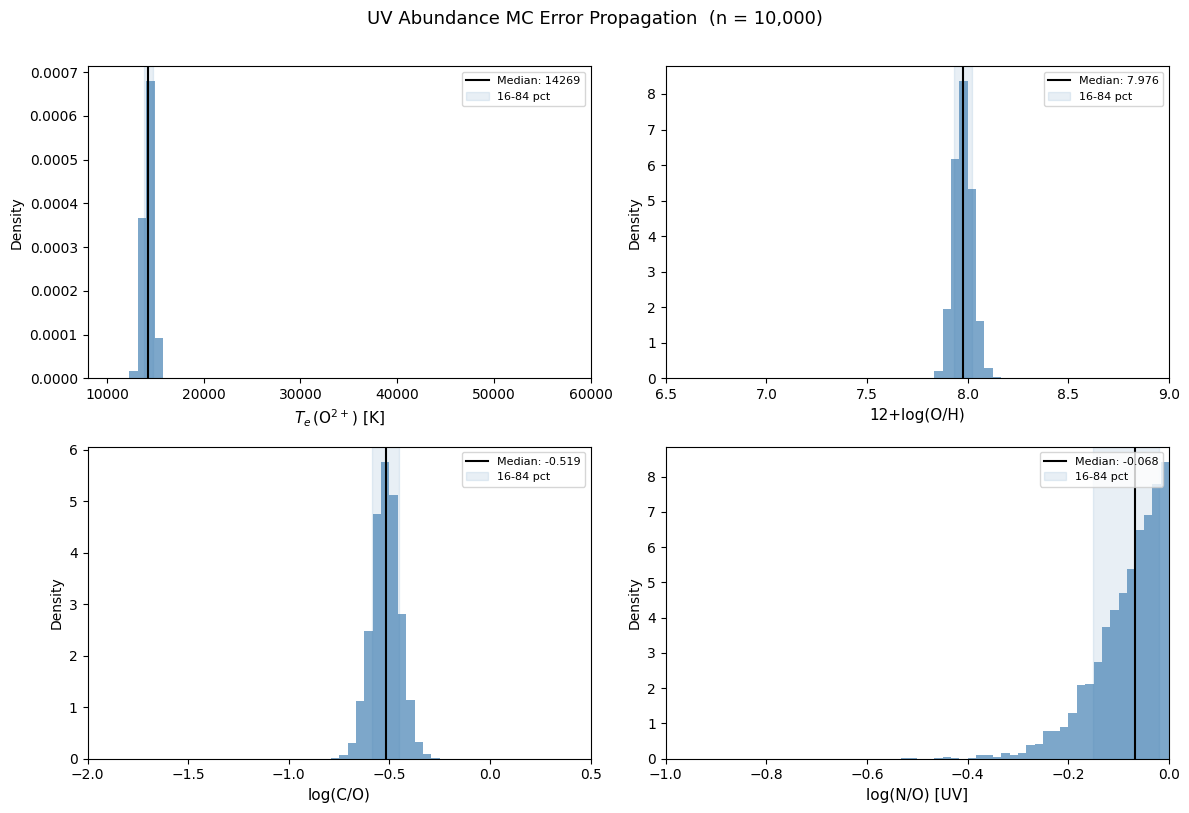

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

quantities = [
    (Te_s, r"$T_e\,(\mathrm{O}^{2+})$ [K]", ".0f", (8000, 60000)),
    (OH_s, r"12+log(O/H)", ".3f", (6.5, 9.0)),
    (CO_s, r"log(C/O)", ".3f", (-2.0, 0.5)),
    (NO_s, r"log(N/O) [UV]", ".3f", (-1, 0.0)),
]

for ax, (arr, label, fmt, (xlo, xhi)) in zip(axes.flat, quantities):
    v = arr[np.isfinite(arr)]
    v = v[(v >= xlo) & (v <= xhi)]
    if len(v) == 0:
        ax.text(0.5, 0.5, "No valid samples", transform=ax.transAxes, ha="center")
        continue
    lo, med, hi = np.percentile(v, [16, 50, 84])

    ax.hist(v, bins=60, color="steelblue", alpha=0.7, density=True,
            range=(xlo, xhi))
    ax.axvline(med, color="k", lw=1.5,
               label=f"Median: {med:{fmt}}")
    ax.axvspan(lo, hi, alpha=0.12, color="steelblue", label="16-84 pct")

    ax.set_xlim(xlo, xhi)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(f"UV Abundance MC Error Propagation  (n = {n_mc:,})", fontsize=13, y=1.01)
plt.tight_layout()

## 10. N/O from three independent tracers

Following Berg+2025 (arXiv:2511.13591), who measure N/O from four
methods on a z = 6.1 galaxy, we compare three approaches:

| # | Tracer | Lines | Method |
|---|--------|-------|--------|
| 1 | N+/O+ | [NII] 6585 / [OII] 3726+3729 | Low-ionisation proxy |
| 2 | Direct sum | (N+ + N2+ + N3+) / (O+ + O2+) | Multi-ion, model-free (Berg+25 eq. 5) |
| 3 | N2+/O2+ | NIII] 1749+1752 / [OIII] 5007 | UV single-zone proxy |

**Method 2** is the most complete: it sums all detected nitrogen
ions (N+, N2+, N3+) and divides by total detected oxygen (O+ + O2+),
avoiding the need for ICFs from photoionisation models.  The only
assumption is that N4+ and O3+ are negligible (N4+ is < 1% of total
N here).

Methods 1 and 3 are single-ion-pair ratios that bracket the true N/O:
N+/O+ underestimates because it misses N in higher stages, while
N2+/O2+ may over- or under-estimate depending on the ICF (Berg+25
find ICF(N2+/O2+) ~ 2.5 from Martinez+25 models).

In [16]:
from jwspecabund.icf import icf_nitrogen

# Te_low from DESI DR2 Te-Te relation
Te_low = 0.648 * Te_high + 3270.0
print(f"Te_high = {Te_high:.0f} K")
print(f"Te_low  = {Te_low:.0f} K  (DESI DR2)")
print(f"ne      = {ne:.0f} cm^-3\n")

# Initialise low-ionisation atoms
O2_atom = pn.Atom('O', 2)
N2_atom = pn.Atom('N', 2)

# O+/H+ from [OII] 3726+3729 at Te_low
f_3726, e_3726 = get_flux(result_oii, "OII_3726")
f_3729, e_3729 = get_flux(result_oii, "OII_3729")
f_oii_total = f_3726 + f_3729
f_oii_c, _ = dust_correct(f_oii_total, 0, 3728.0, Av)

j_Hb_low = get_j_Hb(Te_low, ne)
j_oii = (O2_atom.getEmissivity(Te_low, ne, wave=3726)
         + O2_atom.getEmissivity(Te_low, ne, wave=3729))
Op = (f_oii_c / f_Hb_c) * (j_Hb_low / j_oii)

# N+/H+ from [NII] 6585 at Te_low
f_nii, e_nii = get_flux(result_opt, "NII_6585")
f_nii_c, _ = dust_correct(f_nii, e_nii, REST_LINES_A["NII_6585"], Av)
j_nii = N2_atom.getEmissivity(Te_low, ne, wave=6584)
Np = (f_nii_c / f_Hb_c) * (j_Hb_low / j_nii)

print(f"{'Ion':<8s} {'X/H+':>12s} {'12+log':>10s}")
print("-" * 32)
print(f"{'O+':<8s} {Op:12.3e} {12+np.log10(Op):10.3f}")
print(f"{'O2+':<8s} {Opp:12.3e} {12+np.log10(Opp):10.3f}")
print(f"{'N+':<8s} {Np:12.3e} {12+np.log10(Np):10.3f}")
if np.isfinite(Npp):
    print(f"{'N2+':<8s} {Npp:12.3e} {12+np.log10(Npp):10.3f}")
if np.isfinite(Nppp):
    print(f"{'N3+':<8s} {Nppp:12.3e} {12+np.log10(Nppp):10.3f}")

# --- Three N/O tracers ---
NO_1 = Np / Op                   # N+/O+ (optical)

# Direct sum: (N+ + N2+ + N3+) / (O+ + O2+)  — Berg+25 Method 4
N_sum = Np + sum(x for x in [Npp, Nppp] if np.isfinite(x))
O_sum = Op + Opp
NO_2 = N_sum / O_sum

NO_3 = Npp / Opp                 # N2+/O2+ (UV, matched IPs)

print(f"\n{'Tracer':<45s} {'N/O':>10s} {'log(N/O)':>10s}")
print("-" * 67)
print(f"{'1. N+/O+ (optical)':<45s} {NO_1:10.4f} {np.log10(NO_1):10.3f}")
print(f"{'2. Direct sum (N+ + N2+ + N3+)/(O+ + O2+)':<45s} {NO_2:10.4f} {np.log10(NO_2):10.3f}")
print(f"{'3. N2+/O2+ (UV, matched IPs)':<45s} {NO_3:10.4f} {np.log10(NO_3):10.3f}")

# Breakdown of contributions
print(f"\nDirect sum breakdown:")
print(f"  N+  = {Np/N_sum:.1%}   O+  = {Op/O_sum:.1%}")
n2_frac = Npp/N_sum if np.isfinite(Npp) else 0
n3_frac = Nppp/N_sum if np.isfinite(Nppp) else 0
print(f"  N2+ = {n2_frac:.1%}   O2+ = {Opp/O_sum:.1%}")
print(f"  N3+ = {n3_frac:.1%}")

Te_high = 14305 K
Te_low  = 12540 K  (DESI DR2)
ne      = 46454 cm^-3

Ion              X/H+     12+log
--------------------------------
O+          1.500e-04      8.176
O2+         9.378e-05      7.972
N+          1.459e-06      6.164
N2+         4.981e-05      7.697
N3+         4.839e-05      7.685

Tracer                                               N/O   log(N/O)
-------------------------------------------------------------------
1. N+/O+ (optical)                                0.0097     -2.012
2. Direct sum (N+ + N2+ + N3+)/(O+ + O2+)         0.4089     -0.388
3. N2+/O2+ (UV, matched IPs)                      0.5311     -0.275

Direct sum breakdown:
  N+  = 1.5%   O+  = 61.5%
  N2+ = 50.0%   O2+ = 38.5%
  N3+ = 48.6%


In [17]:
# Add [OII] and [NII] MC draws
extra_lines = {
    "OII_3726": (result_oii, 3727.09),
    "OII_3729": (result_oii, 3729.88),
    "NII_6585": (result_opt, REST_LINES_A["NII_6585"]),
}

for name, (res, rwave) in extra_lines.items():
    f, e = get_flux(res, name)
    if np.isfinite(f) and np.isfinite(e) and e > 0:
        mc_fluxes[name] = rng.normal(f, e, size=n_mc)
    else:
        mc_fluxes[name] = np.full(n_mc, np.nan)
    kv[name] = salim_attenuation(np.array([rwave]), 1.0)[0]

# Pre-compute emissivity grids for the low-ionisation zone
print("Pre-computing low-ionisation emissivity grids ...")
O2_atom = pn.Atom('O', 2)
N2_atom = pn.Atom('N', 2)

j_oii_g = np.array([
    O2_atom.getEmissivity(T, ne, wave=3726)
    + O2_atom.getEmissivity(T, ne, wave=3729)
    for T in Te_g
])
j_nii_g = np.array([
    N2_atom.getEmissivity(T, ne, wave=6584) for T in Te_g
])
j_Hb_any_g = np.array([get_j_Hb(T, ne) for T in Te_g])
print("Done.")

# Te_low per MC sample (DESI DR2 relation)
Te_low_s = 0.648 * Te_s + 3270.0

# Dust-corrected MC fluxes for [OII] and [NII]
c_oii_s = dc("OII_3726") + dc("OII_3729")
c_nii_s = dc("NII_6585")

# Emissivities at Te_low (interpolate on the Te_g grid)
bad_low = ~np.isfinite(Te_low_s)
ej_oii   = np.interp(Te_low_s, Te_g, j_oii_g);   ej_oii[bad_low]   = np.nan
ej_nii   = np.interp(Te_low_s, Te_g, j_nii_g);   ej_nii[bad_low]   = np.nan
ej_Hb_lo = np.interp(Te_low_s, Te_g, j_Hb_any_g); ej_Hb_lo[bad_low] = np.nan

# O+/H+ and N+/H+ at Te_low
with np.errstate(invalid="ignore", divide="ignore"):
    Op_s = np.where(c_oii_s > 0, (c_oii_s / c_Hb) * (ej_Hb_lo / ej_oii), np.nan)
    Np_s = np.where(c_nii_s > 0, (c_nii_s / c_Hb) * (ej_Hb_lo / ej_nii), np.nan)

# --- Three N/O tracers (MC) ---
with np.errstate(invalid="ignore", divide="ignore"):
    # 1. N+/O+ (optical, low-ionisation proxy)
    NO_1_s = np.where(
        (Np_s > 0) & (Op_s > 0),
        np.log10(Np_s / Op_s), np.nan,
    )

    # 2. Direct sum: (N+ + N2+ + N3+) / (O+ + O2+)  — Berg+25 Method 4
    N_sum_s = pos_or_zero(Np_s) + pos_or_zero(Npp_s) + pos_or_zero(Nppp_s)
    O_sum_s = pos_or_zero(Op_s) + pos_or_zero(Opp_s)
    NO_2_s = np.where(
        (N_sum_s > 0) & (O_sum_s > 0),
        np.log10(N_sum_s / O_sum_s), np.nan,
    )

    # 3. N2+/O2+ (UV, matched ionisation potentials)
    NO_3_s = np.where(
        (Npp_s > 0) & (Opp_s > 0),
        np.log10(Npp_s / Opp_s), np.nan,
    )

# Report
def report_no(arr, label):
    v = arr[np.isfinite(arr)]
    if len(v) == 0:
        print(f"  {label:<45s}  no valid samples")
        return
    lo, med, hi = np.percentile(v, [16, 50, 84])
    print(f"  {label:<45s} {med:+.3f}  (+{hi-med:.3f} / -{med-lo:.3f})  [{len(v):,} samples]")

print("log(N/O) from three tracers:\n")
report_no(NO_1_s, "1. N+/O+ (optical)")
report_no(NO_2_s, "2. Direct sum (Berg+25)")
report_no(NO_3_s, "3. N2+/O2+ (UV, matched IPs)")

Pre-computing low-ionisation emissivity grids ...
Done.
log(N/O) from three tracers:

  1. N+/O+ (optical)                            -2.008  (+0.212 / -0.160)  [9,965 samples]
  2. Direct sum (Berg+25)                       -0.402  (+0.144 / -0.142)  [10,000 samples]
  3. N2+/O2+ (UV, matched IPs)                  -0.296  (+0.130 / -0.168)  [9,996 samples]


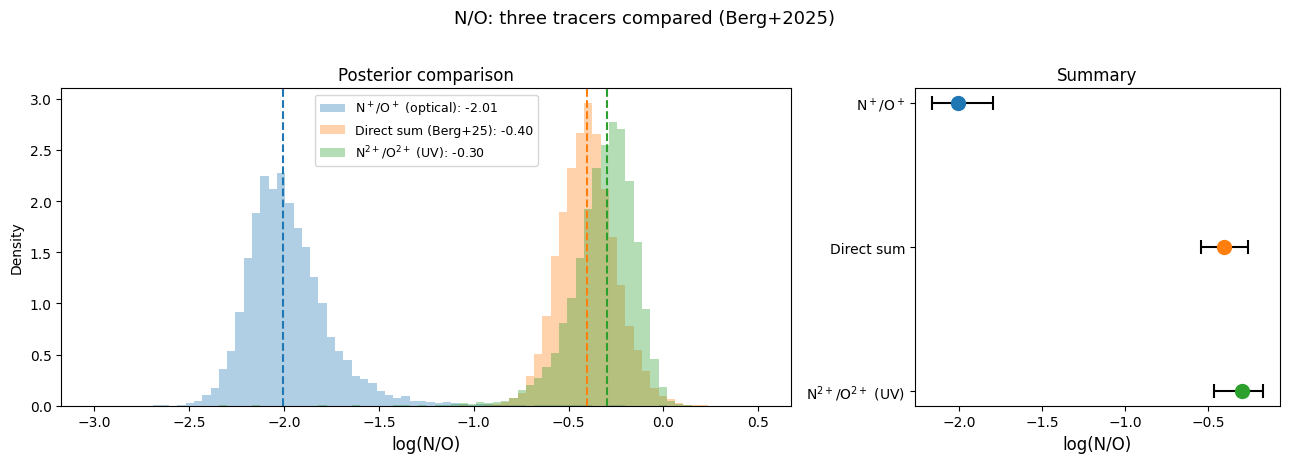

In [18]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 4.5),
    gridspec_kw={"width_ratios": [2, 1]},
)

# Left: overlaid posteriors
xlo, xhi = -3.0, 0.5
labels = [
    r"N$^+$/O$^+$ (optical)",
    r"Direct sum (Berg+25)",
    r"N$^{2+}$/O$^{2+}$ (UV)",
]
colors = ["C0", "C1", "C2"]
all_NO = [NO_1_s, NO_2_s, NO_3_s]

medians, lo_errs, hi_errs = [], [], []
for arr, label, color in zip(all_NO, labels, colors):
    v = arr[np.isfinite(arr)]
    v = v[(v >= xlo) & (v <= xhi)]
    lo, med, hi = np.percentile(v, [16, 50, 84])
    medians.append(med)
    lo_errs.append(med - lo)
    hi_errs.append(hi - med)
    ax1.hist(v, bins=80, color=color, alpha=0.35, density=True,
             range=(xlo, xhi), label=f"{label}: {med:.2f}")
    ax1.axvline(med, color=color, lw=1.5, ls="--")

ax1.set_xlabel(r"log(N/O)", fontsize=12)
ax1.set_ylabel("Density")
ax1.legend(fontsize=9)
ax1.set_title("Posterior comparison")

# Right: error-bar summary
y_pos = np.arange(3)
ax2.errorbar(
    medians, y_pos,
    xerr=[lo_errs, hi_errs],
    fmt="none", capsize=5, capthick=1.5,
    ecolor="k", elinewidth=1.5,
)
for i, (m, c) in enumerate(zip(medians, colors)):
    ax2.plot(m, i, "o", color=c, markersize=10, zorder=5)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([
    r"N$^+$/O$^+$",
    "Direct sum",
    r"N$^{2+}$/O$^{2+}$ (UV)",
], fontsize=10)
ax2.set_xlabel(r"log(N/O)", fontsize=12)
ax2.set_title("Summary")
ax2.invert_yaxis()

fig.suptitle("N/O: three tracers compared (Berg+2025)", fontsize=13, y=1.02)
plt.tight_layout()

## 11. Discussion: why do different N/O tracers disagree?

We measure four different N/O values in this notebook.  They span
~2 dex, from log(N/O) = -2.0 to 0.0, on the **same spectrum**.
The differences are not errors — they reflect which ions are included
and the ionisation structure of the gas.

### Summary of all N/O measurements

| # | Ratio | Value | log(N/O) | Section |
|---|-------|-------|----------|---------|
| A | (N2+ + N3+ + N4+) / O2+ | 1.05 | +0.02 | §7–8 |
| 1 | N+/O+ | 0.010 | -2.01 | §10 |
| 2 | (N+ + N2+ + N3+) / (O+ + O2+) | 0.41 | -0.39 | §10 |
| 3 | N2+/O2+ | 0.53 | -0.28 | §10 |

### Why they disagree

**The ionisation structure is the key.**  This composite spectrum
is highly ionised — the ionic breakdown is:

- **Oxygen:** O+ = 61.5% of total O, O2+ = 38.5%.
  Despite the high ionisation, O+ still dominates because the
  ionisation potential of O+ → O2+ (35.1 eV) is relatively high.
- **Nitrogen:** N+ = 1.5%, N2+ = 50.0%, N3+ = 48.6%, N4+ < 0.3%.
  Nearly all nitrogen is in the N2+ and N3+ stages.
  The ionisation potential of N+ → N2+ (29.6 eV) is lower than
  O+ → O2+, so nitrogen is pushed to higher stages more easily.

This N/O ionisation asymmetry drives the discrepancies:

#### Measurement A: (N2+ + N3+ + N4+) / O2+ = +0.02
This is the "naive UV" ratio from §7.  It sums all UV nitrogen ions
but divides only by O2+.  The problem is **zone mismatch**: N3+
(ionisation potential 77.5 eV) coexists with O3+ (77.4 eV), not O2+
(54.9 eV).  Since we lack O3+/H+ (which requires [O IV] 25.9 µm),
dividing all the nitrogen by only O2+ **overestimates N/O** by a
factor of ~2.6 — the ratio of total O to O2+ alone.

#### Tracer 1: N+/O+ = -2.01
The classical optical proxy.  It assumes N/O ≈ N+/O+, which requires
that nitrogen and oxygen have similar ionisation correction factors
(ICFs).  This holds in low-ionisation H II regions where most N is
N+ and most O is O+.  Here it fails catastrophically because N+ is
only 1.5% of total nitrogen — the [N II] line traces a tiny fraction
of the nitrogen budget.  This tracer **underestimates** N/O by ~1.6 dex.

#### Tracer 2: Direct sum = -0.39 (best estimate)
Following Berg+2025 Method 4, this sums all detected nitrogen ions
(N+, N2+, N3+) and divides by all detected oxygen (O+, O2+).  It is
the most complete, model-free estimate.  The only missing ions are
N4+ (measured to be < 0.3% of N) and O3+ (unmeasured; likely small
given that O+ still dominates).  This is our **best estimate** of
log(N/O) ≈ -0.39.

#### Tracer 3: N2+/O2+ = -0.28
N2+ and O2+ have similar ionisation potentials (47.4 and 54.9 eV),
so they coexist in the same zone — no zone mismatch.  However, this
single-ion ratio only captures one ionisation stage.  It gives
log(N/O) = -0.28, which is ~0.1 dex higher than the direct sum.
The difference arises because the direct sum includes O+ in the
denominator (O+ is 61.5% of O, inflating the denominator relative
to the N2+/O2+ zone alone).  In practice, N2+/O2+ needs an ICF
of order ~2.5 (Martinez+2025) to correct for the missing ions —
consistent with the offset we see.

### Physical interpretation

The direct-sum value log(N/O) ≈ -0.4 is elevated compared to the
solar value (log(N/O)⊙ ≈ -0.86) and the low-metallicity plateau
(log(N/O) ≈ -1.5).  At 12+log(O/H) = 7.98, this composite sits
in the regime where secondary nitrogen production (CNO cycling)
is expected to enhance N/O above the primary plateau — consistent
with the nitrogen-loud galaxies seen at z > 4 by JWST
(e.g. Cameron+2023, Isobe+2023, Topping+2024, Schaerer+2024).

### Recommendations

1. **Use the direct sum** (Tracer 2) as the fiducial N/O when UV
   and optical lines are both available.
2. **Do not use** (N2+ + N3+) / O2+ (Measurement A) — the zone
   mismatch makes it unreliable without an O3+ measurement.
3. **N+/O+ is unreliable** at high ionisation parameter — it
   underestimates N/O by > 1 dex in this stack.
4. **N2+/O2+** is a useful single-zone diagnostic but requires
   an ICF (or comparison with the direct sum) to interpret as
   total N/O.